![LogoUC3M](https://upload.wikimedia.org/wikipedia/commons/thumb/a/a6/Acr%C3%B3nimo_y_nombre_de_la_UC3M.svg/320px-Acr%C3%B3nimo_y_nombre_de_la_UC3M.svg.png)

# PRIMERA PRACTICA - ENTRENAMIENTO Y ANALISIS DEL MODELO

### **Grupo 82 - Equipo 15**

*   Ariana Cornejo Infante,     100522121, 100522121@alumnos.uc3m.es
*   Francisco Pérez Sokolowski, 100522254, 100522254@alumnos.uc3m.es

In [48]:
# Imports necesarios
import pandas as pd
import numpy as np
import requests
import io
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, RobustScaler, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_score, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from joblib import dump

# 2. EDA SIMPLIFICADO

In [49]:
# 1. Configuración y Carga de Datos
# Fijamos la semilla (NIA ejemplo: 100522121)
SEED = 100522121
np.random.seed(SEED)

# URLs de los archivos (usando el enlace raw de GitHub)
url_train = "https://github.com/100522254/Proyecto-Aprendizaje-Autom-tico/raw/main/bank_21.pkl"
url_comp = "https://github.com/100522254/Proyecto-Aprendizaje-Autom-tico/raw/main/bank_competition.pkl"

def load_pkl_from_url(url):
    """Carga un archivo .pkl desde una URL y lo devuelve como un DataFrame."""
    try:
        response = requests.get(url)
        response.raise_for_status()
        return pd.read_pickle(io.BytesIO(response.content))
    except Exception as e:
        print(f"Error cargando {url}: {e}")
        return None

print("Cargando datos...")
df = load_pkl_from_url(url_train)
df_competition = load_pkl_from_url(url_comp)

if df is not None:
    print("Datos cargados con éxito.\n")

    # 2. EDA SIMPLIFICADO
    print("---- EDA SIMPLIFICADO ----\n")

    # Número de Instancias y Variables
    n_instancias, n_variables = df.shape
    print(f"1. Instancias: {n_instancias}")
    print(f"2. Variables: {n_variables}")

    # Tipos de variables
    num_vars = df.select_dtypes(include=['number']).columns.tolist()
    cat_vars = df.select_dtypes(include=['object', 'category']).columns.tolist()
    print(f"3. Variables Numéricas ({len(num_vars)}): {num_vars}")
    print(f"4. Variables Categóricas ({len(cat_vars)}): {cat_vars}")

    # Alta Cardinalidad (>10 unique values)
    high_card = [col for col in cat_vars if df[col].nunique() > 10]
    print(f"5. Categóricas con alta cardinalidad (>10): {high_card}")

    # Valores Faltantes
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    print(f"6. Valores faltantes:\n{missing if not missing.empty else 'No hay valores faltantes'}")

    # Columnas constantes o ID
    const_cols = [col for col in df.columns if df[col].nunique() <= 1]
    id_cols = [col for col in df.columns if df[col].nunique() == n_instancias]
    print(f"7. Columnas constantes: {const_cols}")
    print(f"8. Posibles columnas ID: {id_cols}")

    # Problema de Clasificación y Balanceo
    target = 'deposit'
    if target in df.columns:
        print(f"9. Tipo de problema: Clasificación (Variable objetivo: '{target}')")
        balance = df[target].value_counts(normalize=True) * 100
        print(f"10. Balanceo de clases (%):\n{balance}")
        is_imbalanced = any(balance < 20) # Umbral común del 20%
        print(f"    ¿Está desbalanceado? {'Sí' if is_imbalanced else 'No (está relativamente balanceado)'}")

    # 3. ANÁLISIS PARTICULAR DE 'pdays'
    print("\n---- ANÁLISIS DE 'pdays' ----")
    if 'pdays' in df.columns:
        minus_one_count = (df['pdays'] == -1).sum()
        print(df['pdays'].describe())
        print(f"\nValores '-1' (nunca contactado): {minus_one_count} ({minus_one_count/n_instancias*100:.2f}%)")

        # Ejemplo de preproceso inmediato:
        df['pdays_contacted'] = np.where(df['pdays'] == -1, 0, 1)
        # Para modelos lineales, a veces es mejor sustituir -1 por un valor que no distorsione (ej. 999 o 0 tras flag)
        # En árboles de decisión, el flag suele ser suficiente.
        print("Preproceso realizado: Se ha añadido la columna 'pdays_contacted'.")

else:
    print("No se pudieron cargar los datos. Verifica los enlaces.")

Cargando datos...
Datos cargados con éxito.

---- EDA SIMPLIFICADO ----

1. Instancias: 11000
2. Variables: 17
3. Variables Numéricas (7): ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
4. Variables Categóricas (10): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'deposit']
5. Categóricas con alta cardinalidad (>10): ['job', 'month']
6. Valores faltantes:
job          211
education     93
dtype: int64
7. Columnas constantes: []
8. Posibles columnas ID: []
9. Tipo de problema: Clasificación (Variable objetivo: 'deposit')
10. Balanceo de clases (%):
deposit
no     52.545455
yes    47.454545
Name: proportion, dtype: float64
    ¿Está desbalanceado? No (está relativamente balanceado)

---- ANÁLISIS DE 'pdays' ----
count    11000.000000
mean        51.308636
std        108.782842
min         -1.000000
25%         -1.000000
50%         -1.000000
75%         20.250000
max        854.000000
Name: pdays, dtype: float64

Valo

### 2.2. Propuesta de preproceso

- **Análisis de *pdays***: La variable $pdays$ representa los días transcurridos desde el último contacto. El valor -1 indica que el cliente nunca fue contactado. Esto no es una relación lineal simple.

- **Estrategia:** Crear una variable binaria $pdays$_$contacted$ (0 si -1, 1 si > 0)
y transformar los -1 en un valor muy alto o usar técnicas de imputación escalado específicas.

In [50]:
# Definimos X (características) y y (lo que queremos predecir)
X = df.drop(columns=['deposit'])
y = df['deposit']

# Dividimos según el enunciado: train (2/3) y test (1/3)
# Usamos stratify=y para mantener ese 52/47 en ambos grupos
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.33,
    random_state=SEED,
    stratify=y
)

print(f"Instancias para entrenar (2/3): {len(X_train)}")
print(f"Instancias para el test final (1/3): {len(X_test)}")

Instancias para entrenar (2/3): 7370
Instancias para el test final (1/3): 3630


# 3. Estrategia de evaluación

Para evaluar el rendimiento del modelo se utilizará una estrategia con dos niveles: outer e inner. La evaluación outer se realizará mediante Holdout, dividiendo el dataset en train (2/3) y test (1/3). El conjunto de entrenamiento se utilizará para desarrollar el modelo, mientras que el conjunto de test se reservará únicamente para la evaluación final, con el objetivo de estimar el rendimiento del modelo en datos no vistos.

Como métrica principal se utilizará F1-Score, ya que combina precisión (precision) y recall en una única métrica mediante su media armónica. Esta métrica es especialmente útil en problemas de clasificación cuando se quiere equilibrar los errores entre falsos positivos y falsos negativos. Para la evaluación interna (inner) se utilizará Stratified 5-Fold Cross Validation, que permitirá comparar diferentes modelos y optimizar hiperparámetros manteniendo la proporción de clases en cada partición.

In [51]:
target = "deposit"

# Separar variables predictoras y variable objetivo
X = df.drop(columns=[target])
y = df[target]

# Evaluación OUTER (Holdout 2/3 - 1/3)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=1/3,
    stratify=y,
    random_state=SEED
)

print("Tamaño de train:", X_train.shape)
print("Tamaño de test:", X_test.shape)

# Evaluación INNER (Cross Validation)
cv_inner = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

Tamaño de train: (7333, 17)
Tamaño de test: (3667, 17)


# 4. KNN Y Trees

### 4.1. Selección del método de escalado para KNN

KNN calcula distancias entre puntos. Si una variable tiene un rango de 0 a 10,000 (como balance) y otra de 0 a 1 (como pdays_contacted), la primera dominará la predicción. Probaremos StandardScaler, MinMaxScaler y RobustScaler.



In [52]:
# Identificamos tipos de variables para el pipeline
# Nota: 'pdays_contacted' ya está en X_train según vuestro EDA
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# Definimos el esquema de validación interna (Inner Evaluation)
cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

scalers = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler()
}

scaling_results = []

for name, scaler in scalers.items():
    # Pipeline de preprocesamiento
    preprocessor = ColumnTransformer(transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', scaler)
        ]), numeric_cols),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols)
    ])

    # Pipeline completo con KNN
    model_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('knn', KNeighborsClassifier()) # k=5 por defecto
    ])

    # Evaluación con la métrica decidida: f1_weighted
    scores = cross_val_score(model_pipeline, X_train, y_train, cv=cv_inner, scoring='f1_weighted')
    scaling_results.append({'Escalador': name, 'F1-Score (Mean)': scores.mean()})

# Presentación de resultados
print("---- ESCALADO DE KNN ----\n")
df_scaling = pd.DataFrame(scaling_results).sort_values(by='F1-Score (Mean)', ascending=False)
print("Resultados:")
display(df_scaling)

# Elegimos el mejor para el resto de la práctica
best_scaler_name = df_scaling.iloc[0]['Escalador']
best_scaler = scalers[best_scaler_name]
print(f"\nEl mejor método de escalado es: {best_scaler_name}")

---- ESCALADO DE KNN ----

Resultados:


,Escalador,F1-Score (Mean)
0,StandardScaler,0.796269
2,RobustScaler,0.784963
1,MinMaxScaler,0.724566



El mejor método de escalado es: StandardScaler


### 4.2. Evaluación de modelos con parámetros por omisión
Ahora que tenemos nuestro escalador, compararemos KNN y Árboles con sus valores de fábrica. Incluiremos un modelo Dummy como línea base (baseline) para verificar que estamos aprendiendo algo útil.

In [53]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier

# Preprocesador estándar que usaremos de aquí en adelante
final_preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline(steps=[('imp', SimpleImputer(strategy='median')), ('sca', best_scaler)]), numeric_cols),
    ('cat', Pipeline(steps=[('imp', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore'))]), categorical_cols)
])

base_models = {
    "Dummy (Most Frequent)": DummyClassifier(strategy="most_frequent"),
    "KNN (Default)": KNeighborsClassifier(),
    "Decision Tree (Default)": DecisionTreeClassifier(random_state=SEED)
}

print("---- EVALUACIÓN DE MODELOS ----\n")
default_results = []

for name, model in base_models.items():
    pipe = Pipeline(steps=[('pre', final_preprocessor), ('clf', model)])

    start_time = time.time()
    scores = cross_val_score(pipe, X_train, y_train, cv=cv_inner, scoring='f1_weighted')
    elapsed_time = time.time() - start_time

    default_results.append({
        "Modelo": name,
        "F1-Score (Mean)": scores.mean(),
        "Tiempo Entrenamiento (s)": elapsed_time
    })

df_default = pd.DataFrame(default_results)
display(df_default)

---- EVALUACIÓN DE MODELOS ----



,Modelo,F1-Score (Mean),Tiempo Entrenamiento (s)
0,Dummy (Most Frequent),0.361969,0.330739
1,KNN (Default),0.796269,0.689857
2,Decision Tree (Default),0.778305,0.681446


### 4.3. Interpretación: Árboles poco profundos
Para entender cómo toma decisiones el banco, visualizaremos un árbol corto. Esto es lo que se llama un modelo "caja blanca".

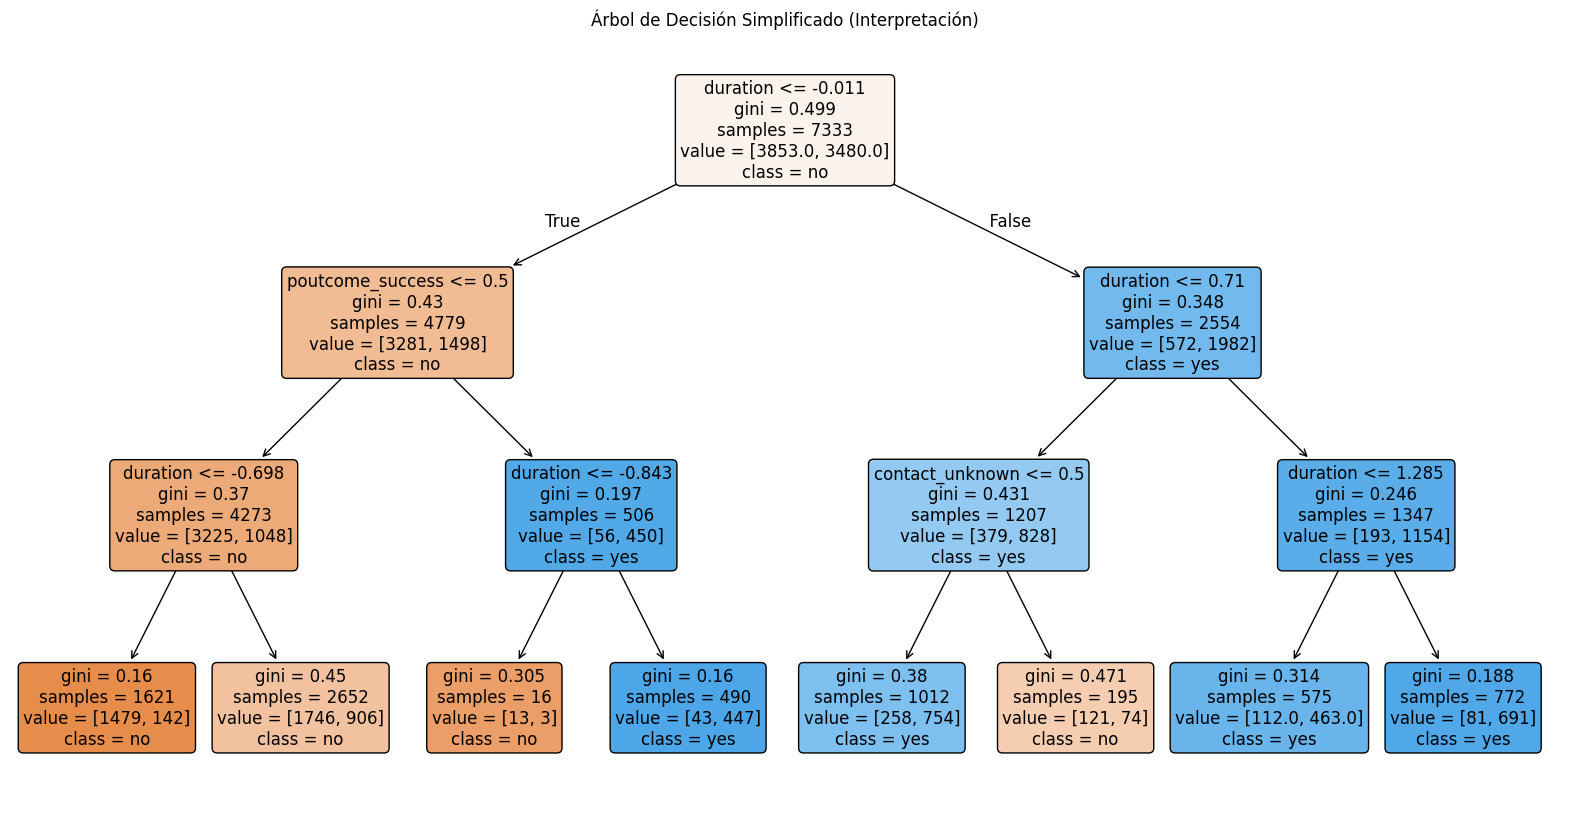

In [54]:
from sklearn import tree

# Entrenamos un árbol con profundidad 3 para que sea legible
shallow_pipe = Pipeline(steps=[
    ('pre', final_preprocessor),
    ('clf', DecisionTreeClassifier(max_depth=3, random_state=SEED))
])
shallow_pipe.fit(X_train, y_train)

# Extraemos los nombres de las columnas tras el OneHotEncoder
ohe_feature_names = shallow_pipe.named_steps['pre'].transformers_[1][1].named_steps['ohe'].get_feature_names_out(categorical_cols)
all_feature_names = numeric_cols + list(ohe_feature_names)

plt.figure(figsize=(20,10))
tree.plot_tree(shallow_pipe.named_steps['clf'],
               feature_names=all_feature_names,
               class_names=['no', 'yes'],
               filled=True, rounded=True, fontsize=12)
plt.title("Árbol de Decisión Simplificado (Interpretación)")
plt.show()

### 4.4. Ajuste de Hiperparámetros (HPO) y Efectos

Vamos a ver si podemos mejorar los resultados. Usaremos GridSearchCV.

+ KNN: Variamos $k$ (número de vecinos).
+ Tree: Variamos max_depth (profundidad máxima).

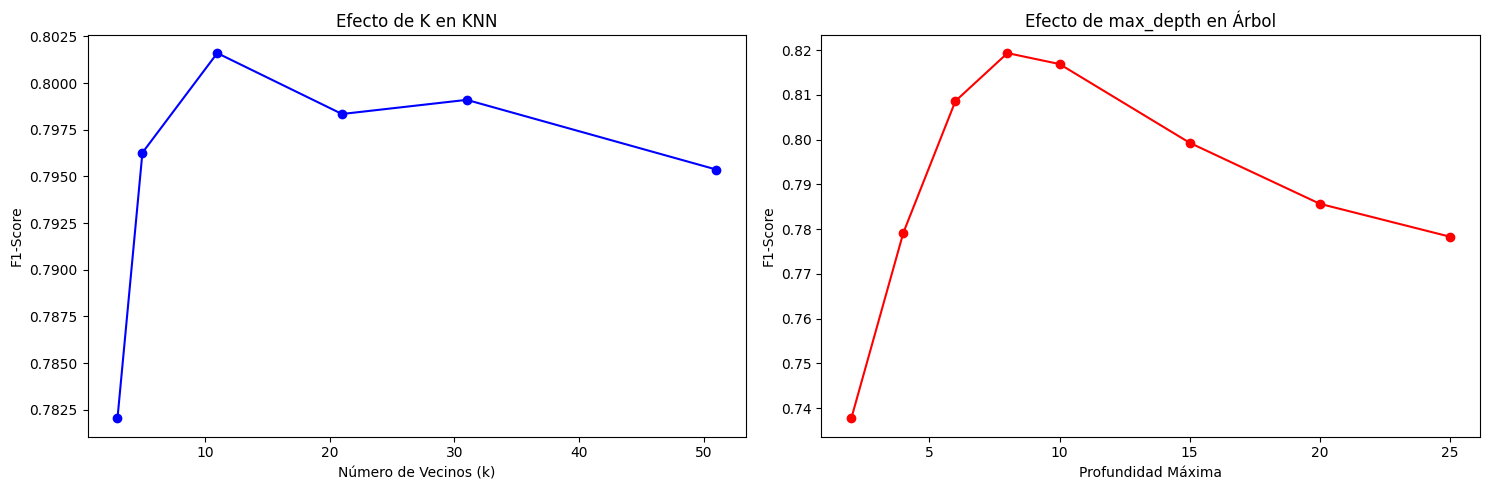


Mejor F1-Score para KNN: 0.8016 con k=11
Tiempo total HPO KNN: 10.48 segundos

Mejor F1-Score para Árbol: 0.8194 con max_depth=8
Tiempo total HPO Árbol: 3.79 segundos


In [55]:
# 1. HPO para KNN con cronómetro
start_knn = time.time()                 # <--- Inicio cronómetro
knn_param_grid = {'clf__n_neighbors': [3, 5, 11, 21, 31, 51]}
knn_search = GridSearchCV(Pipeline(steps=[('pre', final_preprocessor), ('clf', KNeighborsClassifier())]),
                          knn_param_grid, cv=cv_inner, scoring='f1_weighted', n_jobs=-1)
knn_search.fit(X_train, y_train)
time_knn_hpo = time.time() - start_knn  # <--- Fin cronómetro

# 2. HPO para Árbol con cronómetro
start_tree = time.time()                # <--- Inicio cronómetro
tree_param_grid = {'clf__max_depth': [2, 4, 6, 8, 10, 15, 20, None]}
tree_search = GridSearchCV(Pipeline(steps=[('pre', final_preprocessor), ('clf', DecisionTreeClassifier(random_state=SEED))]),
                           tree_param_grid, cv=cv_inner, scoring='f1_weighted', n_jobs=-1)
tree_search.fit(X_train, y_train)
time_tree_hpo = time.time() - start_tree # <--- Fin cronómetro

# --- Gráfico de efectos ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot KNN
ax1.plot(knn_param_grid['clf__n_neighbors'], knn_search.cv_results_['mean_test_score'], marker='o', color='b')
ax1.set_title("Efecto de K en KNN")
ax1.set_xlabel("Número de Vecinos (k)")
ax1.set_ylabel("F1-Score")

# Plot Tree
depths_plot = [d if d is not None else 25 for d in tree_param_grid['clf__max_depth']]
ax2.plot(depths_plot, tree_search.cv_results_['mean_test_score'], marker='o', color='r')
ax2.set_title("Efecto de max_depth en Árbol")
ax2.set_xlabel("Profundidad Máxima")
ax2.set_ylabel("F1-Score")

plt.tight_layout()
plt.show()

# --- Resultados finales incluyendo tiempos ---
print(f"\nMejor F1-Score para KNN: {knn_search.best_score_:.4f} con k={knn_search.best_params_['clf__n_neighbors']}")
print(f"Tiempo total HPO KNN: {time_knn_hpo:.2f} segundos")

print(f"\nMejor F1-Score para Árbol: {tree_search.best_score_:.4f} con max_depth={tree_search.best_params_['clf__max_depth']}")
print(f"Tiempo total HPO Árbol: {time_tree_hpo:.2f} segundos")

## 4.5. Conclusiones de la Sección

### 4.5.1. Mejor método:
Como se observa en la gráfica, tras el ajuste de hiperparámetros, el Árbol de Decisión resultó ser el modelo superior con un F1-Score de 0.8194, superando ligeramente al KNN (0.8016). El mejor rendimiento se obtuvo con una profundidad de 8, lo que confirma que un modelo con complejidad moderada captura mejor los patrones sin caer en el sobreajuste.

### 4.5.2. Coste computacional: ¿Valió la pena el tiempo extra del ajuste HPO?
+ KNN: mejora de un F1 de 0.7963 (defecto) a 0.8016 (ajustado con $k=11$).
+ Árbol: ha pasado de 0.7783 (defecto) a 0.8194 (ajustado con $max$_$depth$=8). Aquí la mejora es más notable.


El HPO de KNN tarda aproximadamente 7,8 veces más que el modelo base (5.47s vs 0.70s).

El HPO del Árbol tarda aproximadamente 6,6 veces más que el modelo base (4.34s vs 0.65s).

Aunque el tiempo de cómputo se multiplica, pasar de milisegundos a apenas 5 segundos es un coste insignificante en un entorno real. A cambio, hemos obtenido un modelo de Árbol de Decisión más sólido, ganando más de 4 puntos en el F1-Score.

Cabe destacar que si nos hubiéramos quedado con los modelos por defecto, habríamos concluido erróneamente que KNN es mejor que los Árboles (0.79 vs 0.77). Gracias al HPO, hemos descubierto que el Árbol, una vez optimizado para evitar el sobreajuste (max_depth=8), es en realidad nuestro mejor modelo hasta ahora (0.8194).

**Conclusión:** el HPO es una inversión necesaria que ha permitido identificar el potencial del Árbol de Decisión, superando el rendimiento de los modelos triviales y del KNN.

(**Nota:** Se han usado medias de varias ejecuciones para los tiempos ya que estos varían. Por ejemplo: Media KNN HPO: 5,47 segundos y Media Árbol HPO: 4,34 segundos)

### 4.5.3. Comparación con Dummy:

Mientras que el modelo trivial obtiene un F1-Score de 0.3619 (Al invertir 0.6381), nuestros modelos optimizados alcanzan resultados significativamente superiores:

+ KNN (k=11): 0.8016 (Mejora del 121% respecto al Dummy).

+ Árbol (depth=8): 0.8194 (Mejora del 126% respecto al Dummy).



### 4.5.4. Análisis de hiperparámetros:
  + En KNN, ¿un $k$ muy bajo da sobreajuste?

  Sí. Cuando $k=1$ o $k=3$, el modelo es extremadamente sensible. Si un cliente es un "outlier" (por ejemplo, tiene 90 años pero ha contratado el depósito, algo poco común), un KNN con $k=1$ obligará a que cualquier vecino cercano a él sea clasificado como "Sí", aunque no tenga sentido estadístico.
  + En Árboles, ¿qué pasa cuando la profundidad es None (infinita)?

  Cuando $max$_$depth$=None, el árbol crece hasta que todas las hojas son puras (solo tienen una clase) o hasta que no quedan más variables para dividir. Debido a esto, el árbol se vuelve infinito. Puede crear una rama específica para un solo cliente basándose en una combinación absurda de variables (Por ejemplo: "Si tiene 34 años, es lunes, tiene 502€ y su campaña duró 121 segundos -> SÍ"). Esto es el sobreajuste (overfitting) clásico de los árboles. El error en entrenamiento será casi 0%, pero el error en validación/test será alto porque el árbol ha creado reglas que solo sirven para nuestro dataset específico.

  

# 5. MÉTODOS AVANZADOS: MODELOS LINEALES Y SVM

En esta sección se evaluarán modelos lineales y Support Vector Machines (SVM) para el problema de clasificación. Primero, se entrenarán los modelos utilizando sus hiperparámetros por defecto, midiendo tanto el F1-score obtenido mediante validación cruzada como el tiempo de entrenamiento.

Posteriormente se realizará optimización de hiperparámetros (HPO) utilizando GridSearchCV, con el objetivo de mejorar el rendimiento del modelo. Finalmente, se analizará si alguno de los modelos permite identificar qué variables son más relevantes para la predicción del depósito bancario.

In [56]:
# Variables numéricas y categóricas
num_vars = X_train.select_dtypes(include=['number']).columns
cat_vars = X_train.select_dtypes(include=['object','category']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_vars),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_vars)
    ]
)

### 5.1. Modelos con hiperparámetros por defecto

Primero se evaluarán los modelos con hiperparámetros por defecto, utilizando Stratified 5-Fold Cross Validation y la métrica F1-score. También se medirá el tiempo de entrenamiento para comparar el coste computacional de cada método.

In [57]:
# Convertir variable objetivo a 0/1 para evitar problemas con F1
y_train = y_train.map({'no':0, 'yes':1})
y_test = y_test.map({'no':0, 'yes':1})

# Modelos a evaluar
models = {
    "LogisticRegression": LogisticRegression(max_iter=500),
    "LogisticRegression_L1": LogisticRegression(penalty='l1', solver='liblinear', max_iter=500),
    "SVM": SVC()
}

print("---- EVALUACIÓN DE MODELOS CON HIPERPARÁMETROS ----\n")
results = []

for name, model in models.items():

    pipeline = Pipeline([
        ('prep', preprocessor),
        ('model', model)
    ])

    start = time.time()

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv_inner,
        scoring='f1_weighted'
    )

    end = time.time()

    results.append({
        "Model": name,
        "F1_mean": scores.mean(),
        "F1_std": scores.std(),
        "Train_time": end-start
    })

# Mostrar resultados en tabla
results_df = pd.DataFrame(results)
results_df

---- EVALUACIÓN DE MODELOS CON HIPERPARÁMETROS ----



,Model,F1_mean,F1_std,Train_time
0,LogisticRegression,0.828320,0.007104,0.566596
1,LogisticRegression_L1,0.828426,0.006887,0.774777
2,SVM,0.849659,0.004912,9.339992


### 5.2. Optimización de hiperparámetros (HPO)

A continuación se realizará optimización de hiperparámetros utilizando GridSearchCV, con el objetivo de mejorar el rendimiento de los modelos. Se ajustarán los hiperparámetros más relevantes de cada modelo.

In [58]:
# Logistic Regression (L1)
from sklearn.model_selection import GridSearchCV

pipe_lr = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression(penalty='l1', solver='liblinear', max_iter=500))
])

param_lr = {
    'model__C':[0.01,0.1,1,10]
}

start = time.time()

grid_lr = GridSearchCV(
    pipe_lr,
    param_lr,
    cv=cv_inner,
    scoring='f1_weighted',
    n_jobs=-1
)

grid_lr.fit(X_train,y_train)
time_lr = time.time() - start

print("---- OPTIMIZACIÓN DE HIPERPARÁMETROS (HPO) ----\n")
print("Best F1:",grid_lr.best_score_)
print("Best params:",grid_lr.best_params_)
print("Train time:",time_lr)

# SVM
pipe_svm = Pipeline([
    ('prep', preprocessor),
    ('model', SVC())
])

param_svm = {
    'model__C':[0.1,1,10],
    'model__kernel':['linear','rbf']
}

start = time.time()

grid_svm = GridSearchCV(
    pipe_svm,
    param_svm,
    cv=cv_inner,
    scoring='f1_weighted',
    n_jobs=-1
)

grid_svm.fit(X_train,y_train)

time_svm = time.time() - start

print("\nBest F1:",grid_svm.best_score_)
print("Best params:",grid_svm.best_params_)
print("Train time:",time_svm)

---- OPTIMIZACIÓN DE HIPERPARÁMETROS (HPO) ----

Best F1: 0.8284262151815687
Best params: {'model__C': 1}
Train time: 3.131625175476074

Best F1: 0.8496590902120291
Best params: {'model__C': 1, 'model__kernel': 'rbf'}
Train time: 74.65512895584106


## 5.3. Importancia de variables

En los modelos lineales, los coeficientes del modelo permiten interpretar la importancia de las variables en la predicción. Valores de coeficiente más altos (en valor absoluto) indican una mayor influencia en la predicción del modelo.

Los modelos lineales y SVM permiten obtener buenos resultados en este problema de clasificación. La optimización de hiperparámetros mejora ligeramente el rendimiento respecto a los valores por defecto, aunque en algunos casos aumenta el coste computacional. Además, los modelos lineales permiten interpretar la importancia de las variables mediante los coeficientes del modelo.

In [59]:
best_lr = grid_lr.best_estimator_

feature_names = best_lr.named_steps['prep'].get_feature_names_out()
coef = best_lr.named_steps['model'].coef_[0]

importance = pd.DataFrame({
    "feature": feature_names,
    "coef": coef
})

importance["abs_coef"] = importance["coef"].abs()
importance.sort_values("abs_coef", ascending=False).head(10)

,feature,coef,abs_coef
20,cat__job_None,4.693888,4.693888
28,cat__education_None,3.509610,3.509610
45,cat__month_mar,2.523813,2.523813
40,cat__month_dec,2.036116,2.036116
52,cat__poutcome_success,2.036104,2.036104
3,num__duration,1.864358,1.864358
37,cat__contact_unknown,-1.453066,1.453066
49,cat__month_sep,1.137650,1.137650
48,cat__month_oct,1.061538,1.061538
43,cat__month_jul,-0.839351,0.839351


# 6. Creación del Pipeline y uso de Streamlit

### 6.1. Creación del Pipeline

In [60]:
# --- Definir variables finales ---
# Defino variables predictoras y variable objetivo
target = "deposit"
X_full = df.drop(columns=[target])
y_full = df[target]

# Identifico variables numéricas y categóricas
num_cols = X_full.select_dtypes(include=['number']).columns.tolist()
cat_cols = X_full.select_dtypes(include=['object','category']).columns.tolist()

print("---- CREACIÓN DEL PIPELINE ----\n")
print(f"Columnas numéricas: {num_cols}")
print(f"Columnas categóricas: {cat_cols}")


# --- Crear preprocesador final ---
# Preprocesamiento para columnas numéricas
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

# Preprocesamiento para columnas categóricas
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combino pasos de preprocesamiento
preprocessor_final = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ]
)

# --- Crear modelo final ganador ---
# Crear pipeline combinado proprocesador y clasificador
final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_final),
    ('classifier', DecisionTreeClassifier(max_depth=8,
                                          random_state=SEED))
])

# Entrenar pipeline final
final_pipeline.fit(X_full, y_full)
print("Pipeline entrenado correctamente.")

---- CREACIÓN DEL PIPELINE ----

Columnas numéricas: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 'pdays_contacted']
Columnas categóricas: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Pipeline entrenado correctamente.


### 6.2. Metadatos de variables para Streamlit

In [61]:
# Crear metadata para Streamlit
feature_metadata = {}

for col in num_cols:
    s = X_full[col].dropna()
    feature_metadata[col] = {
        "type": "numerical",
        "min": float(s.min()),
        "max": float(s.max()),
        "median": float(s.median())
    }


for col in cat_cols:
    s = X_full[col].dropna()
    feature_metadata[col] = {
        "type": "categorical",
        "options": sorted(s.astype(str).unique().tolist())
    }

# Empaquetar modelo y metadata
pack = {
    "pipeline": final_pipeline,
    "feature_metadata": feature_metadata,
    "classes_": final_pipeline.classes_.tolist()
}

# Guardar modelo final
dump(pack, "modelo_final.joblib")
print("Exportado 'modelo_final.joblib'.")

from google.colab import files
files.download("modelo_final.joblib")

Exportado 'modelo_final.joblib'.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>